# 5.2 — Preparatory Estimates for the Experiment

**Virtual lab:** *Ultrafast X-Ray Experiments* (Exp21), FXE @ European XFEL.
**Goal:** exercises 10–21 — size the sample chemistry, the X-ray attenuation in
the jet, the liquid-jet flow speed, the optical-pump parameters (concentration,
focus, fluence, linear-excitation limit) and the emission-spectrometer crystals.

These are (almost) all closed-form estimates and need no VLab data; X-ray
optical constants come from `xraydb` (= CXRO). Where a value must be read from a
figure in the script (e.g. the molar absorptivity $\epsilon(\lambda)$ from
Fig. 3.3), it is exposed as an editable input and clearly flagged.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Run from the repository root and import `vlab_xray` from this repository's
# own `src/`, so that `data/` and `figures/` resolve identically no matter
# where Jupyter was started and an editable install of another copy of the
# package cannot shadow these sources.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src" / "vlab_xray").is_dir())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from vlab_xray import vlab_utils as V

V.use_paper_style()
os.makedirs("figures", exist_ok=True)
NA = V.N_A

## Exercise 10 — Molar masses of the complex and the salt

$[\mathrm{Fe(bipy)_3}]^{2+}$ = Fe + 3 × (2,2'-bipyridine, C$_{10}$H$_8$N$_2$);
the neutral salt adds two chloride counter-ions.

In [2]:
M_bipy = V.molar_mass("C10H8N2")
M_complex = V.molar_mass("Fe(C10H8N2)3")     # [Fe(bipy)3]2+
M_salt = V.molar_mass("FeCl2(C10H8N2)3")     # [Fe(bipy)3]Cl2
print(f"bipy (C10H8N2)          : {M_bipy:8.3f} g/mol")
print(f"[Fe(bipy)3]2+           : {M_complex:8.3f} g/mol")
print(f"[Fe(bipy)3]Cl2 (salt)   : {M_salt:8.3f} g/mol")

bipy (C10H8N2)          :  156.184 g/mol
[Fe(bipy)3]2+           :  524.398 g/mol
[Fe(bipy)3]Cl2 (salt)   :  595.304 g/mol


**Result.** $M([\mathrm{Fe(bipy)_3}]^{2+}) \approx 524.4$ g/mol;
$M([\mathrm{Fe(bipy)_3}]\mathrm{Cl_2}) \approx 595.3$ g/mol.

## Exercise 11 — Concentration from a weighed-in powder (with 3 H$_2$O)

The microcrystalline powder carries 3 waters of crystallisation per formula
unit: $[\mathrm{Fe(bipy)_3}]\mathrm{Cl_2}\cdot 3\,\mathrm{H_2O}$. Dissolve 10 g
to a total volume of 50 mL and compare with neat water.

In [3]:
M_powder = M_salt + 3 * V.molar_mass("H2O")
m, Vsol_L = 10.0, 0.050
n = m / M_powder
c_complex = n / Vsol_L                       # mol/L
c_water = 1000.0 / V.molar_mass("H2O")       # mol/L of pure water (rho = 1 g/mL)
print(f"M(powder, ·3H2O)   : {M_powder:8.3f} g/mol")
print(f"n(10 g)            : {n*1e3:8.3f} mmol")
print(f"c([Fe(bipy)3]2+)   : {c_complex:8.4f} mol/L")
print(f"c(pure water)      : {c_water:8.2f} mol/L")
print(f"water is {c_water/c_complex:,.0f}× more concentrated than the complex")

M(powder, ·3H2O)   :  649.350 g/mol
n(10 g)            :   15.400 mmol
c([Fe(bipy)3]2+)   :   0.3080 mol/L
c(pure water)      :    55.51 mol/L
water is 180× more concentrated than the complex


**Result.** $c \approx 0.31$ mol/L, i.e. the complex is ~180× more dilute than
the solvent water itself — relevant later when comparing X-ray attenuation by
Fe vs. by water (Ex. 12).

## Exercise 12 — X-ray attenuation budget of the jet (Fe vs. water)

**(a)** Transmittance of a 25 µm pure-water jet, 7000–7200 eV.

In [4]:
E = np.linspace(7000, 7200, 400)
d_jet = 25e-4                     # 25 µm in cm
T_water = V.transmission("H2O", E, d_jet)
print(f"T(water, 25 µm): {T_water.min():.4f}–{T_water.max():.4f} over 7000–7200 eV")

T(water, 25 µm): 0.9620–0.9650 over 7000–7200 eV


**(b)** Molar concentration of an atomic iron foil, and the equivalent Fe-foil
thickness that holds as many Fe atoms as the 25 µm solution jet.

In [5]:
rho_Fe = 7.874                    # g/cm3
c_Fe_foil = rho_Fe / V.molar_mass("Fe") * 1000.0   # mol/L (1000 cm3 per L)
t_Fe_equiv = d_jet * (c_complex / c_Fe_foil)       # cm, one Fe per complex
print(f"c(Fe metal)        : {c_Fe_foil:8.2f} mol/L")
print(f"c([Fe(bipy)3]2+)   : {c_complex:8.4f} mol/L  (from Ex. 11)")
print(f"equivalent Fe foil : {t_Fe_equiv*1e4:8.4f} µm  ({t_Fe_equiv*1e7:.1f} nm)")

c(Fe metal)        :   141.00 mol/L
c([Fe(bipy)3]2+)   :   0.3080 mol/L  (from Ex. 11)
equivalent Fe foil :   0.0546 µm  (54.6 nm)


**(c)** Transmission through that fictive Fe foil, 7000–7200 eV, and **(d)** the
comparison of the Fe and water contributions to the attenuation.

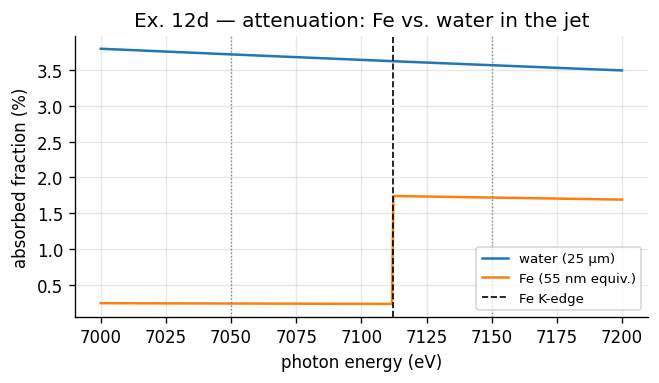

7050 eV:  water  3.72 %   Fe  0.234 %   (Fe/water = 0.063)
7150 eV:  water  3.57 %   Fe  1.717 %   (Fe/water = 0.481)


In [6]:
T_Fe = V.transmission("Fe", E, t_Fe_equiv)
absorb_water = 1 - T_water
absorb_Fe = 1 - T_Fe

fig, ax = plt.subplots(figsize=(5.6, 3.3))
ax.plot(E, absorb_water * 100, label="water (25 µm)")
ax.plot(E, absorb_Fe * 100, label=f"Fe ({t_Fe_equiv*1e7:.0f} nm equiv.)")
ax.axvline(V.FE_K_EDGE_EV, color="k", ls="--", lw=1, label="Fe K-edge")
for e0 in (7050, 7150):
    ax.axvline(e0, color="grey", ls=":", lw=0.8)
ax.set_xlabel("photon energy (eV)"); ax.set_ylabel("absorbed fraction (%)")
ax.set_title("Ex. 12d — attenuation: Fe vs. water in the jet")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig("figures/ex12_attenuation.png", dpi=150); plt.show()

for e0 in (7050.0, 7150.0):
    aw = (1 - V.transmission("H2O", e0, d_jet)) * 100
    af = (1 - V.transmission("Fe", e0, t_Fe_equiv)) * 100
    print(f"{e0:.0f} eV:  water {aw:5.2f} %   Fe {af:6.3f} %   (Fe/water = {af/aw:.3f})")

**(e) Mechanisms.** Between 7000 and 7200 eV the water attenuation is dominated
by the **photoelectric effect** (mostly O 1s photo-ionisation — we are far above
the O K-edge at 543 eV, on the smooth $\sigma\propto E^{-3}$ tail), with a
smaller contribution from **elastic (Rayleigh) and inelastic (Compton)
scattering**. Iron adds essentially no absorption below its K-edge but its cross
section jumps at 7112 eV; despite the tiny equivalent thickness, above the edge
the dilute Fe already contributes a comparable share — which is exactly what
makes element-specific Fe spectroscopy possible in a water-dominated jet.

## Exercise 13 — (script placeholder: `13. TODO`)

This item is left as *TODO* in the script v2.0. It is referenced by the note to
Ex. 15 as the definition of the **optical density**,
$\mathrm{OD} = \epsilon\, c\, d$ (Sec. 3.1), which is what the following
exercises use, so we simply record that relation here.

In [7]:
print("Working relation carried forward:  OD = ε · c · d   (decadic, Sec. 3.1)")

Working relation carried forward:  OD = ε · c · d   (decadic, Sec. 3.1)


## Exercise 14 — Minimum liquid-jet flow speed

Within a pulse train the intra-train repetition rate is 1.1 MHz. To present a
fresh sample to every pulse, the jet must move at least one beam diameter
between pulses. For a 10 µm top-hat X-ray spot:
$$v_\mathrm{min} = d_\mathrm{beam}\times f_\mathrm{rep}.$$

In [8]:
d_beam = 10e-6            # m (top-hat, 10 µm)
f_rep = 1.1e6            # Hz (intra-train)
v_min = d_beam * f_rep
print(f"pulse interval       : {1/f_rep*1e9:.0f} ns")
print(f"minimum flow speed   : {v_min:.1f} m/s")

pulse interval       : 909 ns
minimum flow speed   : 11.0 m/s


**Result.** $v_\mathrm{min}\approx 11$ m/s — well within the ≤30 m/s the FXE
liquid jets provide (Sec. 6.5.1). If the pump spot is larger than the probe
(Ex. 18) the *probed* volume still only needs to clear the X-ray footprint, but
a larger excited region can call for a faster jet to avoid accumulation.

## Exercise 15 — Concentration for OD = 1 at three pump wavelengths

$c = \mathrm{OD}/(\epsilon\, d)$ with $d = 25$ µm and the wavelength-dependent
molar absorptivity $\epsilon(\lambda)$ of $[\mathrm{Fe(bipy)_3}]^{2+}$.

> **Read from Fig. 3.3 / VLab.** The $\epsilon$ values below are representative
> literature figures for the MLCT/LMCT region; replace them with the values you
> read off the UV/VIS spectrum in the script or the app.

In [9]:
OD = 1.0
d_opt = 25e-4                             # cm
eps = {355: 4500.0, 400: 2500.0, 515: 8700.0}   # M^-1 cm^-1  (EDIT with Fig. 3.3)
print("λ (nm)   ε (M⁻¹cm⁻¹)   c(OD=1) (mol/L)   c (mM)")
c_OD = {}
for lam, e in eps.items():
    c = OD / (e * d_opt)
    c_OD[lam] = c
    print(f"  {lam:>3}       {e:>6.0f}         {c:8.4f}       {c*1e3:6.1f}")

λ (nm)   ε (M⁻¹cm⁻¹)   c(OD=1) (mol/L)   c (mM)
  355         4500           0.0889         88.9
  400         2500           0.1600        160.0
  515         8700           0.0460         46.0


**Result.** Higher $\epsilon$ (near the 515 nm MLCT band) needs the *lowest*
concentration for OD = 1 — economical on sample and giving uniform excitation
across the jet thickness.

## Exercise 16 — Choice of the excitation wavelength

Available pulse energies: 5 µJ (355 nm), 15 µJ (515 nm), 50 µJ (400 nm).

**Choice: 515 nm.** It sits on the $^1$MLCT absorption band (Fig. 3.3), so it
populates the singlet MLCT state *directly and selectively* — the well-defined
starting point for the relaxation cascade studied here (Sec. 3.2/3.3). 400 nm
and 355 nm reach higher/mixed bands (LMCT, ligand-centred) and open additional
relaxation channels that would complicate the interpretation (cf. the
multiphoton caution in Ex. 19). The 15 µJ available at 515 nm is far more than
the linear-excitation budget computed next, so pulse energy is not limiting.

In [10]:
lam_exc = 515                      # nm  (chosen)
E_pulse_avail = 15e-6              # J   (available at 515 nm)
print(f"Chosen pump: {lam_exc} nm, up to {E_pulse_avail*1e6:.0f} µJ available.")
print(f"Working concentration (OD=1): c = {c_OD[lam_exc]*1e3:.1f} mM")

Chosen pump: 515 nm, up to 15 µJ available.
Working concentration (OD=1): c = 46.0 mM


## Exercise 17 — Diffraction-limited focal diameter of the pump

A collimated $D = 10$ mm (FWHM) beam focused by an $f = 250$ mm lens. Using the
Rayleigh criterion for the focal spot, $d = 2.44\,\lambda f / D$.

In [11]:
D_in = 10e-3; f_lens = 250e-3
lam_m = lam_exc * 1e-9
d_focus = 2.44 * lam_m * f_lens / D_in
print(f"pump {lam_exc} nm,  f/D = {f_lens/D_in:.1f}")
print(f"diffraction-limited focus diameter: {d_focus*1e6:.1f} µm")

pump 515 nm,  f/D = 25.0
diffraction-limited focus diameter: 31.4 µm


**Result.** $d_\mathrm{focus}\approx 31$ µm — already larger than the ~10 µm
X-ray focus (Ex. 9), which is the desired ordering for a clean pump–probe
overlap.

## Exercise 18 — Relative pump/probe beam sizes (qualitative)

To probe a **uniformly excited** volume, the optical pump must overfill the
X-ray probe: every molecule the X-rays interrogate should have seen the same
(near-plateau) pump fluence. Placing the pump focus slightly *behind* the jet
expands its footprint on the sample beyond the diffraction limit of Ex. 17,
giving a flat-topped excitation region larger than the ~10 µm probe.

Consequence for Ex. 14: a larger excited footprint means more sample must be
refreshed per train, so it can raise the required jet speed.

In [12]:
d_probe = 10.0       # µm  (X-ray focus, Ex. 9)
d_pump = 30.0        # µm  (chosen pump footprint on sample; ≥ d_focus, overfills probe)
print(f"probe (X-ray): ~{d_probe:.0f} µm    pump (optical): ~{d_pump:.0f} µm  "
      f"(ratio {d_pump/d_probe:.1f}× → uniform excitation across the probe)")

probe (X-ray): ~10 µm    pump (optical): ~30 µm  (ratio 3.0× → uniform excitation across the probe)


## Exercise 19 — Linear-excitation limit: photons ≤ molecules

For clean single-photon MLCT excitation, the number of pump photons per pulse
should not exceed the number of ground-state molecules in the excited volume;
otherwise multiphoton absorption populates unwanted higher states.

In [13]:
# (a) molecules in the laser-illuminated volume
A_eff = 1.13 * (d_pump * 1e-4) ** 2          # cm^2  (Gaussian A_eff = 1.13 d_fwhm^2, App. B)
V_exc = A_eff * d_jet                          # cm^3  (× jet thickness 25 µm)
c_work = c_OD[lam_exc]                          # mol/L working concentration
N_mol = c_work * 1e-3 * NA * V_exc              # molecules  (mol/L → mol/cm^3 via 1e-3)
print(f"(a) pump footprint d = {d_pump:.0f} µm → A_eff = {A_eff*1e8:.0f} µm²,  "
      f"V_exc = {V_exc*1e12:.2f} pL")
print(f"    N_molecules in excited volume ≈ {N_mol:.3e}")

# (b) pulse energy at which N_photons = N_molecules
E_photon = V.photon_energy_joule(lam_exc)       # J
E_linear = N_mol * E_photon                      # J
print(f"(b) single-photon energy at {lam_exc} nm: {E_photon/V.E_CHARGE:.2f} eV")
print(f"    pulse energy for N_photons = N_molecules: {E_linear*1e6:.3f} µJ")
print(f"    (available 15 µJ ⇒ attenuate by ~{E_pulse_avail/E_linear:.0f}× to stay linear)")
print("(c) cross-check with the VLab /Laser photon-number calculator and screenshot it.")

(a) pump footprint d = 30 µm → A_eff = 1017 µm²,  V_exc = 25425.00 pL
    N_molecules in excited volume ≈ 7.040e+11
(b) single-photon energy at 515 nm: 2.41 eV
    pulse energy for N_photons = N_molecules: 0.272 µJ
    (available 15 µJ ⇒ attenuate by ~55× to stay linear)
(c) cross-check with the VLab /Laser photon-number calculator and screenshot it.


**Result.** With a 30 µm pump footprint and the OD = 1 concentration, roughly
$10^{12}$ molecules sit in the excited volume; matching the photon number needs a
pulse energy of order **0.3 µJ**. The 15 µJ on tap must therefore be attenuated
by ~50× to keep the excitation in the linear (single-MLCT) regime.

## Exercise 20 — Which emission spectrometer?

**von Hamos.** It is a *dispersive* spectrometer that records the entire Fe
K$\beta$ region simultaneously on a 2-D detector, with no scanning
(Sec. 4.5 / 6.5.2). For a transient experiment that needs the whole
K$\beta_{1,3}$ + K$\beta'$ line shape at every time delay, single-shot capture of
the full spectrum is exactly right. The Johann scanning spectrometer is ~100×
more efficient for a *single* energy but must scan to build a spectrum and
requires per-point incident-intensity normalisation — better suited to a narrow
line of interest than to a full dispersive K$\beta$ measurement.

## Exercise 21 — Analyser crystals and Bragg angles for Fe K$\beta_{1,3}$

For the von Hamos geometry we need a crystal whose Bragg reflection sits at a
large, well-resolved angle across the K$\beta'$ (7045 eV) — K$\beta_{1,3}$
(7058 eV) range, with good reflectivity and enough angular spread to disperse
the band over the detector. $\theta = \arcsin(n\lambda/2d_{hkl})$.

crystal      d [Å]   θ@Kβ' (7045)  θ@Kβ1,3 (7058)
Si(5, 3, 1)  0.9180    73.44°   73.09°
Ge(6, 2, 0)  0.8946    79.62°   79.06°
Ge(5, 3, 1)  0.9564    66.94°   66.69°
Si(4, 4, 0)  0.9601    66.42°   66.18°
Ge(4, 4, 0)  1.0002    61.62°   61.42°
Ge(4, 4, 4)  0.8166      —       —  

Angular dispersion across the Kβ band (Δθ, larger = better resolved):
  Si(5, 3, 1):  Δθ =  21.1 arcmin  (θ ≈ 73.1°)
  Ge(6, 2, 0):  Δθ =  33.7 arcmin  (θ ≈ 79.1°)
  Ge(5, 3, 1):  Δθ =  14.8 arcmin  (θ ≈ 66.7°)
  Si(4, 4, 0):  Δθ =  14.4 arcmin  (θ ≈ 66.2°)
  Ge(4, 4, 0):  Δθ =  11.7 arcmin  (θ ≈ 61.4°)


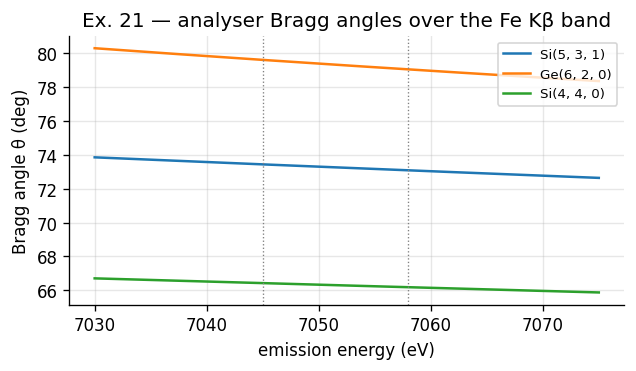

In [14]:
candidates = [("Si", (5, 3, 1)), ("Ge", (6, 2, 0)), ("Ge", (5, 3, 1)),
              ("Si", (4, 4, 0)), ("Ge", (4, 4, 0)), ("Ge", (4, 4, 4))]
E_band = {"Kβ' (7045)": 7045.0, "Kβ1,3 (7058)": V.FE_KB13_EV}
print(f"{'crystal':<10}{'d [Å]':>8}   " + "  ".join(f"θ@{k}" for k in E_band))
rows = []
for mat, hkl in candidates:
    d = V.d_spacing(mat, hkl)
    ths = [V.bragg_angle(e, mat, hkl) for e in E_band.values()]
    spread = (ths[0] - ths[1]) if np.all(np.isfinite(ths)) else np.nan
    rows.append((mat, hkl, d, ths, spread))
    ths_str = "  ".join(f"{t:6.2f}°" if np.isfinite(t) else "   —  " for t in ths)
    print(f"{mat}{hkl!s:<8}{d:8.4f}   {ths_str}")

print("\nAngular dispersion across the Kβ band (Δθ, larger = better resolved):")
for mat, hkl, d, ths, spread in rows:
    if np.isfinite(spread):
        print(f"  {mat}{hkl}:  Δθ = {spread*60:5.1f} arcmin  (θ ≈ {ths[1]:.1f}°)")

# visualise
fig, ax = plt.subplots(figsize=(5.4, 3.2))
Egrid = np.linspace(7030, 7075, 200)
for mat, hkl in [("Si", (5, 3, 1)), ("Ge", (6, 2, 0)), ("Si", (4, 4, 0))]:
    th = V.bragg_angle(Egrid, mat, hkl)
    ax.plot(Egrid, th, label=f"{mat}{hkl}")
for e0, lbl in [(7045, "Kβ'"), (7058, "Kβ1,3")]:
    ax.axvline(e0, color="grey", ls=":", lw=0.8)
ax.set_xlabel("emission energy (eV)"); ax.set_ylabel("Bragg angle θ (deg)")
ax.set_title("Ex. 21 — analyser Bragg angles over the Fe Kβ band")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig("figures/ex21_bragg.png", dpi=150); plt.show()

**Result / discussion.** Reflections with $\theta$ in the ~73–80° range
(e.g. **Si(531)** at ≈73° or **Ge(620)** at ≈79°) give the high angular
dispersion and near-back-reflection resolution wanted for the closely spaced
K$\beta'$/K$\beta_{1,3}$ features, while still reaching both energies (some
high-index reflections such as Ge(444) cannot diffract 7058 eV at all — $\theta$
undefined). The final pick trades resolution (higher $\theta$) against the
energy window and reflectivity; confirm reflectivity/efficiency and the FXE
crystal availability with the Bragg calculator [28] and the FXE crystal list [29].

---
**Section 5.2 complete.** Sample chemistry, jet attenuation, flow speed, pump
wavelength/concentration/focus/fluence, the linear-excitation limit and the
spectrometer crystals are all fixed. Proceed to
`03_experiment_acquisition.ipynb`.